# Step:1 Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# step:2 Load data

In [ ]:
df = pd.read_csv("insurance.csv")

# step:3 EDA

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(1337, 7)

# step:4 Train_test_split

In [ ]:
X = df.drop("charges",axis=1)
y = df["charges"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# step:5 Visualizations

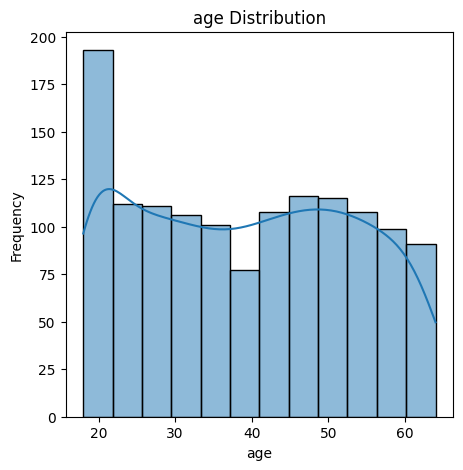

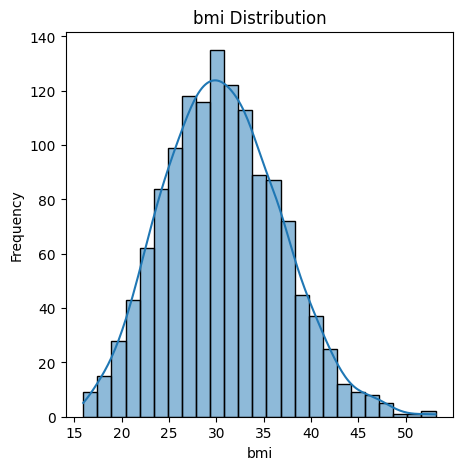

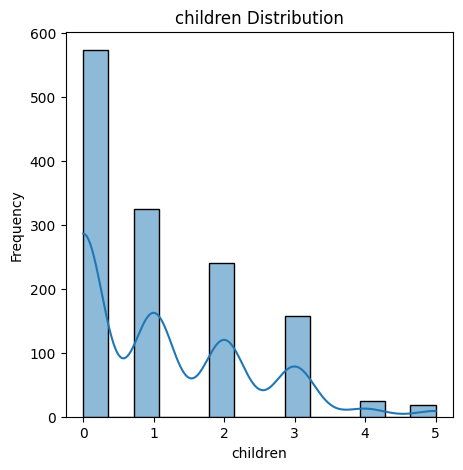

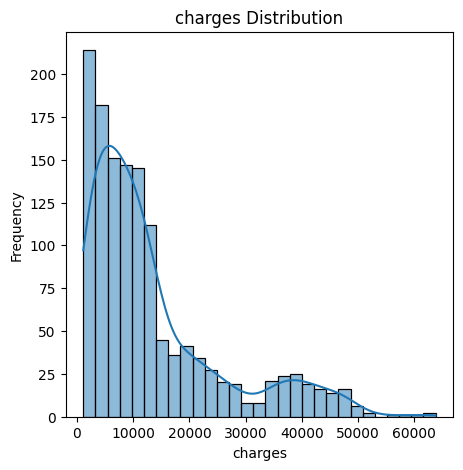

In [ ]:
numerical_cols = ["age","bmi","children","charges"]
for col in numerical_cols:
  plt.figure(figsize=(5,5))
  sns.histplot(df[col],kde=True)
  plt.title(f"{col} Distribution")
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.show()

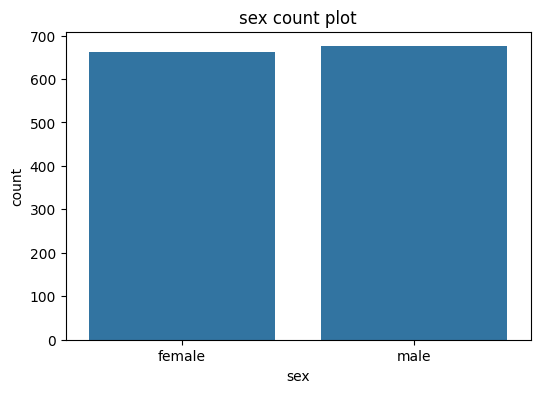

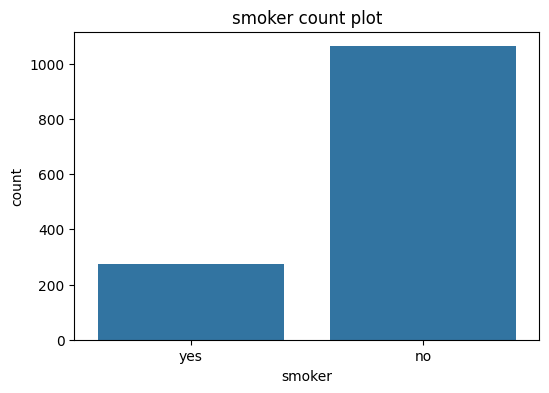

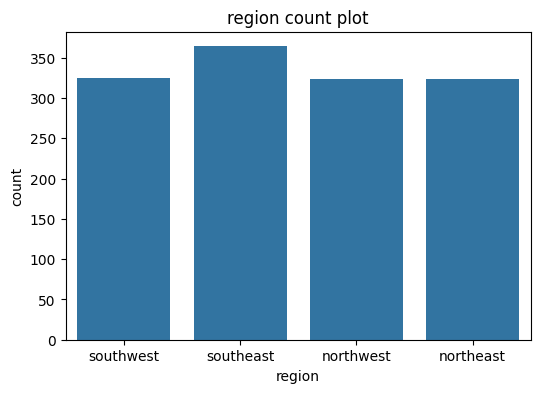

In [ ]:
categorical_cols = ["sex","smoker","region"]
for col in categorical_cols:
  plt.figure(figsize=(6,4))
  sns.countplot(x=col,data=df)
  plt.title(f"{col} count plot")
  plt.show()

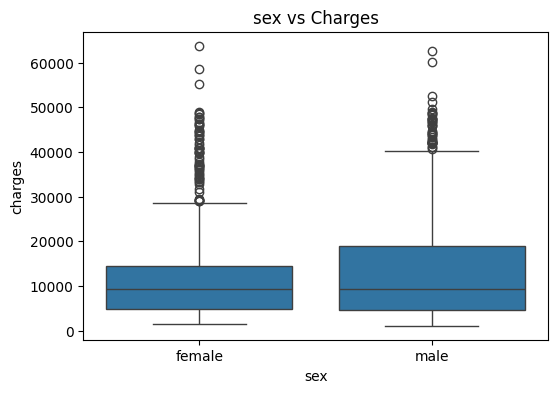

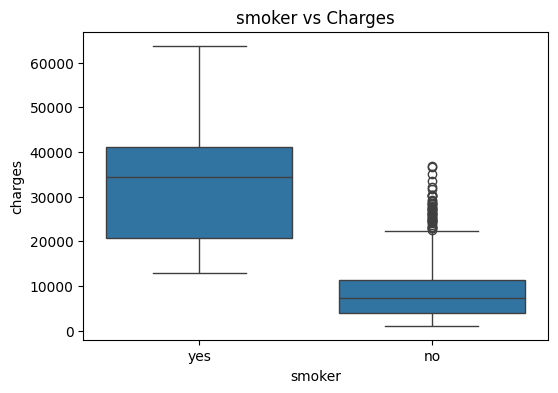

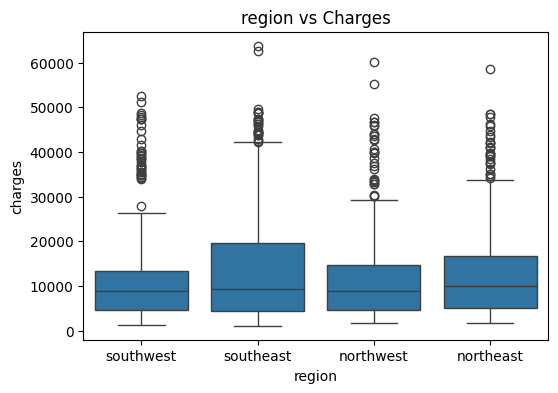

In [ ]:
categorical_cols = ['sex', 'smoker', 'region']

for col in categorical_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=col, y='charges', data=df)

    plt.title(f"{col} vs Charges")

    plt.show()

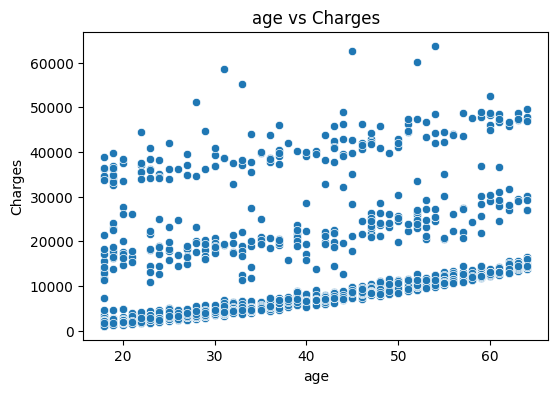

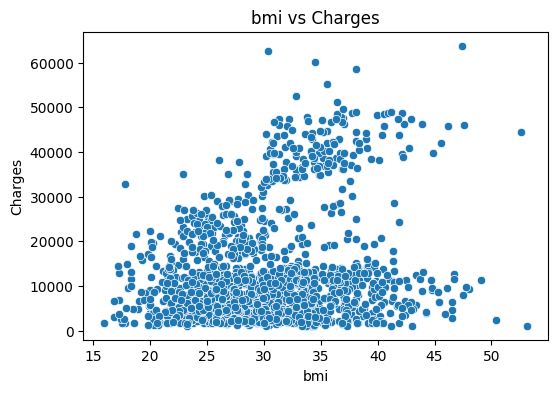

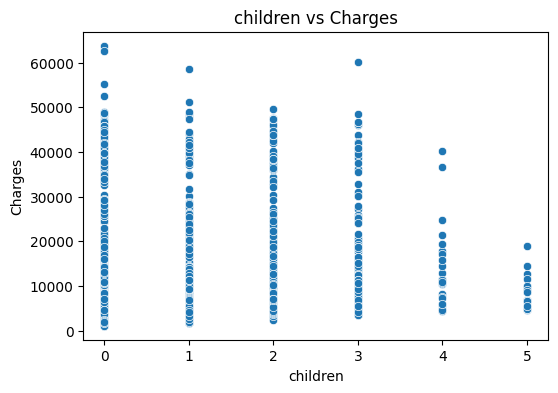

In [ ]:
numerical_cols = ['age', 'bmi', 'children']

for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.scatterplot(x=df[col], y=df['charges'])

    plt.title(f"{col} vs Charges")

    plt.xlabel(col)

    plt.ylabel("Charges")

    plt.show()

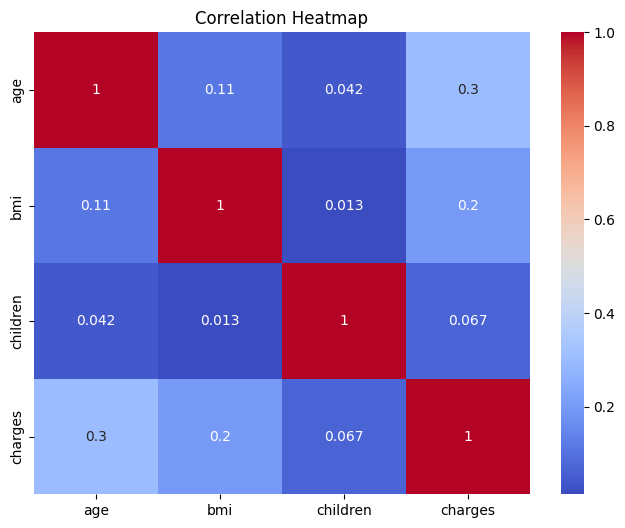

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# step:6 checking multicollinearity

In [ ]:
numerical_cols = ["age", "bmi", "children"]
vif_data = pd.DataFrame()
vif_data["feature"] = numerical_cols
vif_data["VIF"] = [
    variance_inflation_factor(df[numerical_cols].values, i)
    for i in range(len(numerical_cols))
]
print(vif_data)

    feature       VIF
0       age  7.542947
1       bmi  7.856685
2  children  1.797373


# step: 7 Building models

In [ ]:
categorical_cols = ["sex","smoker","region"]
numerical_cols = ["age","bmi","children"]
preprocessor = ColumnTransformer(
    transformers=[("num",StandardScaler(),numerical_cols),
                  ("cat",OneHotEncoder(drop="first"),categorical_cols)]
)
lr_pipeline = Pipeline(steps=[("preprocess",preprocessor),("reg",LinearRegression())])
ridge_pipeline = Pipeline(steps=[("preprocess",preprocessor),("reg",Ridge())])
lasso_pipeline = Pipeline(steps=[("preprocess",preprocessor),("reg",Lasso())])
dt_pipeline = Pipeline(steps=[("preprocess",preprocessor),("reg",DecisionTreeRegressor())])
rf_pipeline = Pipeline(steps=[("preprocess",preprocessor),("reg",RandomForestRegressor(random_state=42))])

grid_params = {
    "Linear_Regression": {
        "algo": lr_pipeline,
        "params": {}
    },

    "Ridge_Regression": {
        "algo":ridge_pipeline,
        "params":{
        "reg__alpha": [0.001,0.01,0.1,1]}
    },
    "Lasso_Regression": {
        "algo": lasso_pipeline,
        "params": {
        "reg__alpha": [0.001,0.01,0.1,1]}
    },
    "Decision_Tree": {
        "algo":dt_pipeline,
        "params":{
        "reg__max_depth": [3,5,7,10],
        "reg__min_samples_split": [2,5,10]
        }
    },
    "Random_Forest":{
        "algo":rf_pipeline,
        "params": {
        "reg__n_estimators": [50,100],
        "reg__max_depth": [5,10],
        "reg__min_samples_split": [2,5]}
    }
}
results = []
for name,model in grid_params.items():
  reg = GridSearchCV(model["algo"],model["params"],cv=5,return_train_score=False,scoring="r2",verbose=1,n_jobs=-1)
  reg.fit(X_train,y_train)
  best_model = reg.best_estimator_
  y_pred = best_model.predict(X_test)
  R2 = r2_score(y_test,y_pred)
  MSE = mean_squared_error(y_test,y_pred)
  MAE =mean_absolute_error(y_test,y_pred)
  RMSE = np.sqrt(MSE)
  results.append({
      "model_name":name,
      "best_params":reg.best_params_,
      "model":best_model,
      "R2":R2,
      "MSE":MSE,
      "MAE":MAE,
      "RMSE":RMSE
  })
results_df = pd.DataFrame(results)
print(results_df)



Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
          model_name                                        best_params  \
0  Linear_Regression                                                 {}   
1   Ridge_Regression                                  {'reg__alpha': 1}   
2   Lasso_Regression                                  {'reg__alpha': 1}   
3      Decision_Tree  {'reg__max_depth': 5, 'reg__min_samples_split'...   
4      Random_Forest  {'reg__max_depth': 5, 'reg__min_samples_split'...   

                                               model        R2           MSE  \
0  (ColumnTransformer(transformers=[('num', Stand...  0.806929  3.547802e+07   
1  (ColumnTransformer(transformers=[('num', Stand...  0.805921  3.566313e+07   
2  (Colum

In [ ]:
pd.DataFrame(results)

,model_name,best_params,model,R2,MSE,MAE,RMSE
0,Linear_Regression,{},"(ColumnTransformer(transformers=[('num', Stand...",0.806929,3.547802e+07,4177.045561,5956.342894
1,Ridge_Regression,{'reg__alpha': 1},"(ColumnTransformer(transformers=[('num', Stand...",0.805921,3.566313e+07,4193.891909,5971.861741
2,Lasso_Regression,{'reg__alpha': 1},"(ColumnTransformer(transformers=[('num', Stand...",0.806846,3.549317e+07,4177.778109,5957.614852
3,Decision_Tree,"{'reg__max_depth': 5, 'reg__min_samples_split'...","(ColumnTransformer(transformers=[('num', Stand...",0.894090,1.946166e+07,2656.839079,4411.537636
4,Random_Forest,"{'reg__max_depth': 5, 'reg__min_samples_split'...","(ColumnTransformer(transformers=[('num', Stand...",0.901642,1.807384e+07,2418.645551,4251.333642


In [ ]:
for result in results:

    if result["model_name"] == "Random_Forest":

        selected_model = result["model"]

In [ ]:
selected_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('reg',
                 RandomForestRegressor(max_depth=5, min_samples_split=5,
                                       random_state=42))])

In [ ]:
selected_model.score(X_test,y_test)*100

90.16422242801816

# step:8 Visualization

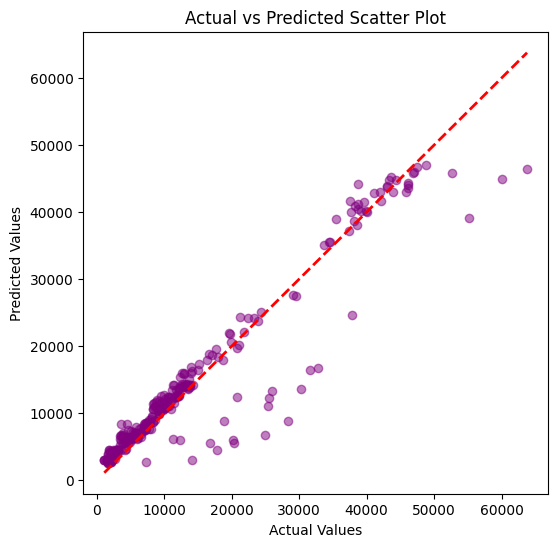

In [ ]:
y_pred = selected_model.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred,
    color='purple',
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    lw=2
)

plt.xlabel('Actual Values')

plt.ylabel('Predicted Values')

plt.title('Actual vs Predicted Scatter Plot')

plt.show()

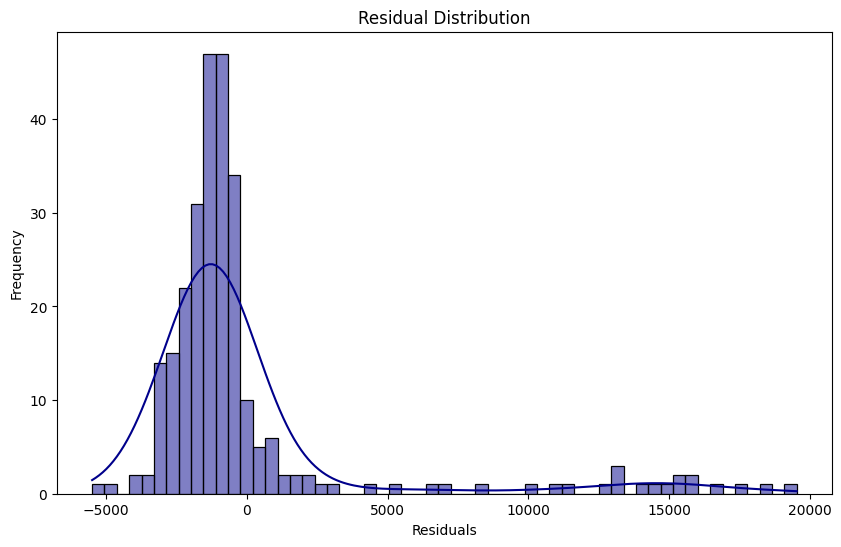

In [ ]:
# Residual Distribution Plot

predictions_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

predictions_df["Residual"] = (
    predictions_df["Actual"] -
    predictions_df["Predicted"]
)

plt.figure(figsize=(10,6))

sns.histplot(
    predictions_df['Residual'],
    kde=True,
    color='darkblue'
)

plt.xlabel('Residuals')

plt.ylabel('Frequency')

plt.title('Residual Distribution')

plt.show()

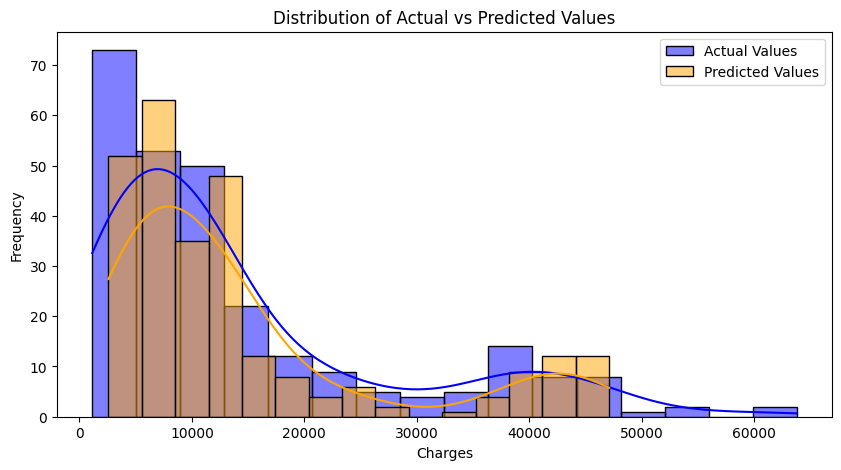

In [ ]:
# Distribution of Actual vs Predicted Values

plt.figure(figsize=(10,5))

sns.histplot(
    y_test,
    kde=True,
    color='blue',
    label='Actual Values',
    alpha=0.5
)

sns.histplot(
    y_pred,
    kde=True,
    color='orange',
    label='Predicted Values',
    alpha=0.5
)

plt.xlabel('Charges')

plt.ylabel('Frequency')

plt.title('Distribution of Actual vs Predicted Values')

plt.legend()

plt.show()